      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Features (X) after processing:
   area  bedrooms  bathrooms  stories  parking  mainroad_yes  guest

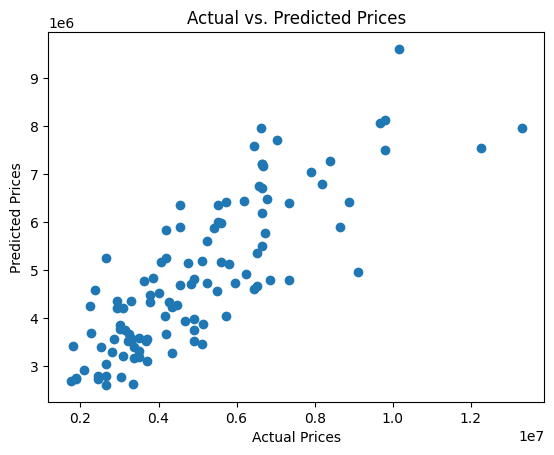

In [6]:
# Program adapted for Housing_Price_Data.csv with multiple features
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the new dataset
try:
    data = pd.read_csv("/Housing_Price_Data.csv")
    print(data.head())

    # Define independent variables (X) and dependent variable (y)
    # Using all columns except 'price' as independent variables
    # Need to handle categorical variables - for simplicity, let's start with numerical ones
    # and then consider how to encode categorical ones like 'mainroad', 'furnishingstatus', etc.
    # For now, let's select numerical columns that seem relevant for prediction
    # Based on the head() output, 'area', 'bedrooms', 'bathrooms', 'stories', 'parking' are numerical
    # We'll need to address categorical columns like 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus'
    # For this modification, let's include all columns and handle categorical ones by converting them to numerical if possible or dropping for simplicity initially.
    # Let's try using a subset of numerical columns first.
    # X = data[['area', 'bedrooms', 'bathrooms', 'stories', 'parking']] # Independent variables
    # y = data['price'] # Dependent variable

    # To include all columns, we need to handle categorical features. One way is one-hot encoding.
    # Let's select all columns except 'price' as features and then apply one-hot encoding.
    X = data.drop('price', axis=1)
    y = data['price']

    # Convert categorical variables into dummy/indicator variables (one-hot encoding)
    X = pd.get_dummies(X, drop_first=True) # drop_first=True avoids multicollinearity

    print("\nFeatures (X) after processing:")
    print(X.head())


    # Split the data into training and testing sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Create and train the Linear Regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = model.predict(X_test)

    # Print model coefficients
    print("\nModel Coefficients (for each feature):")
    # Pair feature names with their coefficients
    coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': model.coef_})
    print(coef_df)
    print("\nIntercept(c):", model.intercept_)

    # Evaluate the model
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print("\nModel Evaluation:")
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"Root Mean Squared Error (RMSE): {rmse}")
    print(f"R-squared (R2): {r2}")


    # Plotting for multiple linear regression is not a simple 2D scatter plot
    # We can plot predicted vs actual values to visualize performance
    plt.scatter(y_test, y_pred)
    plt.xlabel("Actual Prices")
    plt.ylabel("Predicted Prices")
    plt.title("Actual vs. Predicted Prices")
    plt.show()


except FileNotFoundError:
    print("Error: Housing_Price_Data.csv not found. Please make sure the file is in the correct directory.")
except KeyError as e:
    print(f"Error: Column {e} not found in the dataset. Please check the column names in your CSV file.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")